## 1. Import packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors 

from sklearn.metrics import silhouette_score


%matplotlib inline

# plot style
sns.set(color_codes=True)

In [2]:
roommates_df = pd.read_csv('./Data/Roommate Survey (csv).csv')

In [3]:
roommates_df.head()

,Id,Gender,Age,daily routine,Living Environment,Cooking at Home,pet owner,Smoking,Sociable,hobbies & activities,communication method,important roommate qualities,study habits,physical exercise
0,3002,Male,19,Balanced Throughout the Day,Lively,Occasionally,no,Non-Smoker,Open to Socializing,"Sports, Music, Outdoor Activities",Text,Friendly,collaborative,Occasionally (1-2 times a month)
1,3003,Male,19,Night Owl,Balanced,Rarely,yes,Smoker,Prefer Privacy,"Sports, Music, Movies/TV, Gaming",In-person,Respectful,collaborative,Regularly (1-2 times a week)
2,3004,Female,18,Early Riser,Quiet,Regularly,no,Non-Smoker,Open to Socializing,"Reading, Movies/TV",In-person,Respectful,quiet and focused,Regularly (1-2 times a week)
3,3005,Male,18,Balanced Throughout the Day,Balanced,Rarely,no,Non-Smoker,Open to Socializing,"Sports, Movies/TV, Outdoor Activities",In-person,Respectful,quiet and focused,Occasionally (1-2 times a month)
4,3006,Female,19,Balanced Throughout the Day,Quiet,Regularly,no,Non-Smoker,Open to Socializing,Reading,In-person,Cleanliness,quiet and focused,Rarely (once a month or less)


In [4]:
data = roommates_df.drop(columns=["Id"], axis=1).copy()

In [5]:
data.head()

,Gender,Age,daily routine,Living Environment,Cooking at Home,pet owner,Smoking,Sociable,hobbies & activities,communication method,important roommate qualities,study habits,physical exercise
0,Male,19,Balanced Throughout the Day,Lively,Occasionally,no,Non-Smoker,Open to Socializing,"Sports, Music, Outdoor Activities",Text,Friendly,collaborative,Occasionally (1-2 times a month)
1,Male,19,Night Owl,Balanced,Rarely,yes,Smoker,Prefer Privacy,"Sports, Music, Movies/TV, Gaming",In-person,Respectful,collaborative,Regularly (1-2 times a week)
2,Female,18,Early Riser,Quiet,Regularly,no,Non-Smoker,Open to Socializing,"Reading, Movies/TV",In-person,Respectful,quiet and focused,Regularly (1-2 times a week)
3,Male,18,Balanced Throughout the Day,Balanced,Rarely,no,Non-Smoker,Open to Socializing,"Sports, Movies/TV, Outdoor Activities",In-person,Respectful,quiet and focused,Occasionally (1-2 times a month)
4,Female,19,Balanced Throughout the Day,Quiet,Regularly,no,Non-Smoker,Open to Socializing,Reading,In-person,Cleanliness,quiet and focused,Rarely (once a month or less)


## 3. Descriptive statistics of data


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Gender                        428 non-null    object
 1   Age                           428 non-null    object
 2   daily routine                 428 non-null    object
 3   Living Environment            428 non-null    object
 4   Cooking at Home               428 non-null    object
 5   pet owner                     428 non-null    object
 6   Smoking                       428 non-null    object
 7   Sociable                      428 non-null    object
 8   hobbies & activities          428 non-null    object
 9   communication method          428 non-null    object
 10  important roommate qualities  428 non-null    object
 11  study habits                  427 non-null    object
 12  physical exercise             426 non-null    object
dtypes: object(13)
memory

### Fill missing data (mode)


In [7]:
data = data.apply(lambda x: x.fillna(x.mode()[0]))

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Gender                        428 non-null    object
 1   Age                           428 non-null    object
 2   daily routine                 428 non-null    object
 3   Living Environment            428 non-null    object
 4   Cooking at Home               428 non-null    object
 5   pet owner                     428 non-null    object
 6   Smoking                       428 non-null    object
 7   Sociable                      428 non-null    object
 8   hobbies & activities          428 non-null    object
 9   communication method          428 non-null    object
 10  important roommate qualities  428 non-null    object
 11  study habits                  428 non-null    object
 12  physical exercise             428 non-null    object
dtypes: object(13)
memory

## Convert to numerical

In [9]:
for column in data:
    unique_values = data[column].unique()
    print(f"Unique values for {column}:\n{unique_values}\n")


Unique values for Gender:
['Male' 'Female']

Unique values for Age:
['19' '18' '< 18' '20' '21' '22' '>22']

Unique values for daily routine:
['Balanced Throughout the Day' 'Night Owl' 'Early Riser']

Unique values for Living Environment:
['Lively' 'Balanced' 'Quiet']

Unique values for Cooking at Home:
['Occasionally' 'Rarely' 'Regularly']

Unique values for pet owner:
['no' 'yes']

Unique values for Smoking:
['Non-Smoker' 'Smoker']

Unique values for Sociable:
['Open to Socializing' 'Prefer Privacy']

Unique values for hobbies & activities:
['Sports, Music, Outdoor Activities' 'Sports, Music, Movies/TV, Gaming'
 'Reading, Movies/TV' 'Sports, Movies/TV, Outdoor Activities' 'Reading'
 'Outdoor Activities' 'Reading, Music, Movies/TV'
 'Music, Movies/TV, Gaming' 'Sports, Movies/TV'
 'Reading, Sports, Outdoor Activities, Gaming'
 'Reading, Sports, Outdoor Activities'
 'Sports, Music, Movies/TV, Outdoor Activities, Gaming'
 'Sports, Outdoor Activities, Gaming'
 'Reading, Sports, Music, Mov

In [10]:
def encode_categorical_data(data):
    # Binary Encoding
    binary_columns = ['Gender', 'pet owner', 'Smoking', 'Sociable', 'communication method']
    binary_mapping = {'no': 0, 'yes': 1, 'Non-Smoker': 0, 'Smoker': 1, 'Open to Socializing': 1, 'Prefer Privacy': 0, 'Male': 0, 'Female': 1, 'Text': 0, 'In-person': 1}
    data[binary_columns] = data[binary_columns].apply(lambda col: col.map(binary_mapping))
    
    # Ordinal Encoding
    age_mapping = {'< 18': 17, '18': 18, '19': 19, '20': 20, '21': 21, '22': 22, '>22': 23}
    data['Age'] = data['Age'].map(age_mapping)
    
    # Label Encoding
    label_encoded_columns = ['daily routine', 'Living Environment', 'Cooking at Home', 'study habits']
    label_mapping = {'Early Riser': 0, 'Balanced Throughout the Day': 1, 'Night Owl': 2, 'Quiet': 0, 'Balanced': 1, 'Lively': 2,
                     'Occasionally': 0, 'Rarely': 1, 'Regularly': 2, 'quiet and focused': 0, 'collaborative': 1, 'prefer background noise': 2}
    data[label_encoded_columns] = data[label_encoded_columns].apply(lambda col: col.map(label_mapping))

    # Frequency-based Encoding
    exercise_mapping = {'Never': 0, 'Rarely (once a month or less)': 1, 'Occasionally (1-2 times a month)': 2,
                        'Regularly (1-2 times a week)': 3, 'Frequently (3-4 times a week)': 4, 'Very frequently (5 or more times a week)': 5}
    data['physical exercise'] = data['physical exercise'].map(exercise_mapping)

    # One-Hot Encoding
    hobbies_split = data['hobbies & activities'].str.get_dummies(sep=', ')
    data = pd.concat([data, hobbies_split], axis=1)
    data.drop(columns=['hobbies & activities'], inplace=True)

    # One-Hot Encoding 
    qualities_encoded = pd.get_dummies(data['important roommate qualities'], prefix='qualities')
    data = pd.concat([data, qualities_encoded], axis=1).drop(columns=['important roommate qualities'])
    


    return data

data = encode_categorical_data(data)

print(data.head())


   Gender  Age  daily routine  Living Environment  Cooking at Home  pet owner  \
0       0   19              1                   2                0          0   
1       0   19              2                   1                1          1   
2       1   18              0                   0                2          0   
3       0   18              1                   1                1          0   
4       1   19              1                   0                2          0   

   Smoking  Sociable  communication method  study habits  ...  Movies/TV  \
0        0         1                     0             1  ...          0   
1        1         0                     1             1  ...          1   
2        0         1                     1             0  ...          1   
3        0         1                     1             0  ...          1   
4        0         1                     1             0  ...          0   

   Music  Outdoor Activities  Reading  Sports  qualities

In [11]:
data.describe()

,Gender,Age,daily routine,Living Environment,Cooking at Home,pet owner,Smoking,Sociable,communication method,study habits,...,Movies/TV,Music,Outdoor Activities,Reading,Sports,qualities_Cleanliness,qualities_Friendly,qualities_Quiet,qualities_Respectful,qualities_Responsible
count,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,...,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000
mean,0.623832,17.962617,0.803738,0.897196,1.016355,0.231308,0.028037,0.614486,0.801402,0.516355,...,0.514019,0.485981,0.399533,0.422897,0.497664,0.427570,0.179907,0.058411,0.282710,0.051402
std,0.484990,1.158819,0.800342,0.703748,0.747964,0.422163,0.165273,0.487286,0.399412,0.672103,...,0.500388,0.500388,0.490376,0.494598,0.500580,0.495305,0.384559,0.234794,0.450844,0.221074
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,18.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,23.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
for column in data:
    unique_values = data[column].unique()
    print(f"Unique values for {column}:\n{unique_values}\n")


Unique values for Gender:
[0 1]

Unique values for Age:
[19 18 17 20 21 22 23]

Unique values for daily routine:
[1 2 0]

Unique values for Living Environment:
[2 1 0]

Unique values for Cooking at Home:
[0 1 2]

Unique values for pet owner:
[0 1]

Unique values for Smoking:
[0 1]

Unique values for Sociable:
[1 0]

Unique values for communication method:
[0 1]

Unique values for study habits:
[1 0 2]

Unique values for physical exercise:
[2 3 1 0 4 5]

Unique values for Gaming:
[0 1]

Unique values for Movies/TV:
[0 1]

Unique values for Music:
[1 0]

Unique values for Outdoor Activities:
[1 0]

Unique values for Reading:
[0 1]

Unique values for Sports:
[1 0]

Unique values for qualities_Cleanliness:
[0 1]

Unique values for qualities_Friendly:
[1 0]

Unique values for qualities_Quiet:
[0 1]

Unique values for qualities_Respectful:
[0 1]

Unique values for qualities_Responsible:
[0 1]



In [13]:
print(data.isnull().sum())

Gender                   0
Age                      0
daily routine            0
Living Environment       0
Cooking at Home          0
pet owner                0
Smoking                  0
Sociable                 0
communication method     0
study habits             0
physical exercise        0
Gaming                   0
Movies/TV                0
Music                    0
Outdoor Activities       0
Reading                  0
Sports                   0
qualities_Cleanliness    0
qualities_Friendly       0
qualities_Quiet          0
qualities_Respectful     0
qualities_Responsible    0
dtype: int64


In [14]:
data.head()

,Gender,Age,daily routine,Living Environment,Cooking at Home,pet owner,Smoking,Sociable,communication method,study habits,...,Movies/TV,Music,Outdoor Activities,Reading,Sports,qualities_Cleanliness,qualities_Friendly,qualities_Quiet,qualities_Respectful,qualities_Responsible
0,0,19,1,2,0,0,0,1,0,1,...,0,1,1,0,1,0,1,0,0,0
1,0,19,2,1,1,1,1,0,1,1,...,1,1,0,0,1,0,0,0,1,0
2,1,18,0,0,2,0,0,1,1,0,...,1,0,0,1,0,0,0,0,1,0
3,0,18,1,1,1,0,0,1,1,0,...,1,0,1,0,1,0,0,0,1,0
4,1,19,1,0,2,0,0,1,1,0,...,0,0,0,1,0,1,0,0,0,0


In [15]:
from sklearn.feature_selection import VarianceThreshold

variance_threshold = VarianceThreshold(threshold=0.1)

X_high_variance = variance_threshold.fit_transform(data)


In [16]:
X = X_high_variance

C:\Users\zahra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\zahra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zahra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\zahra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

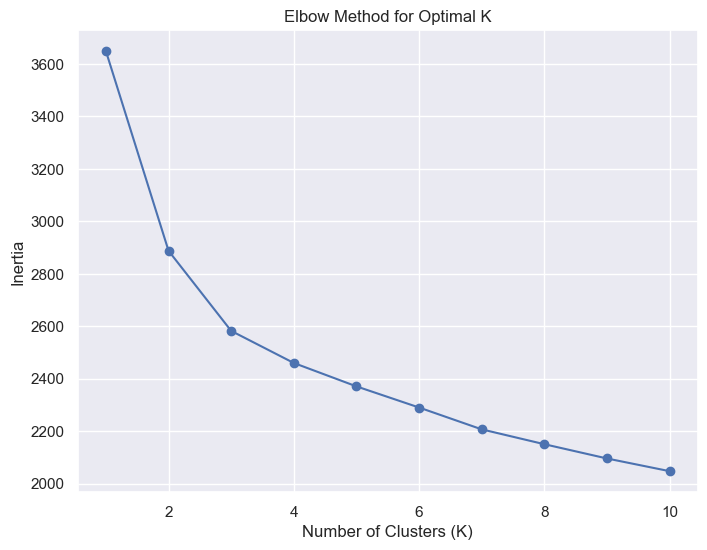

In [17]:

k_values = range(1, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()



In [18]:
def perform_kmeans_clustering(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    return labels

In [19]:
def calculate_silhouette_score(X, labels):
    try:
        silhouette_avg = silhouette_score(X, labels)
        print(f"Silhouette Score: {silhouette_avg}")
    except ValueError as e:
        print(f"Error calculating silhouette score: {e}")

In [20]:
k_value = 3  
kmeans_labels = perform_kmeans_clustering(X, k_value)
calculate_silhouette_score(X, kmeans_labels)

data['Cluster'] = kmeans_labels

C:\Users\zahra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\zahra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Silhouette Score: 0.1920854075122769


In [21]:
X = data.drop(columns=['Cluster']).values


In [22]:
def get_knn_recommendations(target_row_index, k=2, num_recommendations=5):
    target_row = X[target_row_index].reshape(1, -1)
    
    # Identify the cluster of the target
    target_cluster = data.loc[data.index[target_row_index], 'Cluster']
    
    # Filter data for the same cluster
    cluster_data = data[data['Cluster'] == target_cluster]
    
    cluster_data = cluster_data.drop(columns=['Cluster'])
    
    knn = NearestNeighbors(n_neighbors=num_recommendations)
    knn.fit(cluster_data)
    
    # Find the k-Nearest Neighbors
    distances, indices = knn.kneighbors(target_row)
    
    # Get roommate IDs of neighbors
    neighbor_roommates = cluster_data.iloc[indices[0]].index
    
    return neighbor_roommates.tolist()[1:]  # Exclude the target roommate itself




In [23]:
target_roommate_index = 0  
recommendations = get_knn_recommendations(target_roommate_index, k=2, num_recommendations=5)

print(f"Recommendations for Roommate {target_roommate_index + 1}: {recommendations}")

Recommendations for Roommate 1: [217, 84, 87, 192]


C:\Users\zahra\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
